In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('creditcard.csv')

In [4]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [6]:
df =df.dropna()

In [7]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
valid = df[df['Class'] == 0]
print('Valid Transactions: {}'.format(len(df[df['Class'] == 0])))

Valid Transactions: 85054


In [9]:
fraud = df[df['Class'] == 1]
print('Fraud Transactions:{}'.format(len(df[df['Class'] == 1])))

Fraud Transactions:204


In [10]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()


Amount details of the fraudulent transaction


count     204.000000
mean      101.986814
std       229.008970
min         0.000000
25%         1.000000
50%         7.550000
75%        99.990000
max      1809.680000
Name: Amount, dtype: float64

In [11]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    85054.000000
mean        98.365392
std        268.470093
min          0.000000
25%          7.690000
50%         27.000000
75%         89.800000
max      19656.530000
Name: Amount, dtype: float64

In [36]:
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Separate features and target
X = df.drop('Class', axis=1)
Y = df['Class']

print("Original class distribution:", Counter(Y))

# Oversampling using RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority')
X, Y = oversample.fit_resample(X, Y)
print("Oversampled class distribution:", Counter(Y))


Original class distribution: Counter({0.0: 85054, 1.0: 204})
Oversampled class distribution: Counter({0.0: 85054, 1.0: 85054})


In [40]:
# prompt: i want to know how many values are there in Y for class 0 & 1

# Count the number of values for each class in Y
class_counts = Counter(Y)

# Print the counts
print("Number of values for class 0:", class_counts[0])
print("Number of values for class 1:", class_counts[1])


Number of values for class 0: 85054
Number of values for class 1: 85054


In [14]:
print(X.shape)
print(Y.shape)
xData = X.values
yData = Y.values


(170108, 30)
(170108,)


In [21]:
from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit_transform(df)

array([[0.00000000e+00, 9.43114320e-01, 7.92887897e-01, ...,
        2.20791504e-01, 7.61171987e-03, 0.00000000e+00],
       [0.00000000e+00, 9.86831151e-01, 7.96587293e-01, ...,
        2.21614617e-01, 1.36850197e-04, 0.00000000e+00],
       [1.64793514e-05, 9.43139215e-01, 7.79054596e-01, ...,
        2.19901175e-01, 1.92638273e-02, 0.00000000e+00],
       ...,
       [9.99967041e-01, 9.86462183e-01, 7.85045821e-01, ...,
        2.22052775e-01, 6.15520644e-03, 0.00000000e+00],
       [9.99983521e-01, 9.80570728e-01, 7.90993266e-01, ...,
        2.22035725e-01, 9.76774639e-03, 0.00000000e+00],
       [1.00000000e+00, 9.86992986e-01, 7.90302086e-01, ...,
        2.22014127e-01, 6.60849092e-04, 0.00000000e+00]])

In [23]:
X, Y

(         Time         V1        V2         V3         V4         V5        V6  \
 0           0  -1.359807 -0.072781   2.536347   1.378155  -0.338321  0.462388   
 1           0   1.191857  0.266151   0.166480   0.448154   0.060018 -0.082361   
 2           1  -1.358354 -1.340163   1.773209   0.379780  -0.503198  1.800499   
 3           1  -0.966272 -0.185226   1.792993  -0.863291  -0.010309  1.247203   
 4           2  -1.158233  0.877737   1.548718   0.403034  -0.407193  0.095921   
 ...       ...        ...       ...        ...        ...        ...       ...   
 170103  41273 -11.682215  6.332882 -13.297109   7.690772 -10.889891 -2.792360   
 170104  41164  -5.932778  4.571743  -9.427247   6.577056  -6.115218 -3.661798   
 170105  55311  -6.159607  1.468713  -6.850888   5.174706  -2.986704 -1.795054   
 170106  18399 -14.474437  6.503185 -17.712632  11.270352  -4.150142 -3.372098   
 170107  41194  -7.896886  5.381020  -8.451162   7.963928  -7.862419 -2.376820   
 
              

In [24]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)
rfc.fit(xTrain, yTrain)
yPred = rfc.predict(xTest)

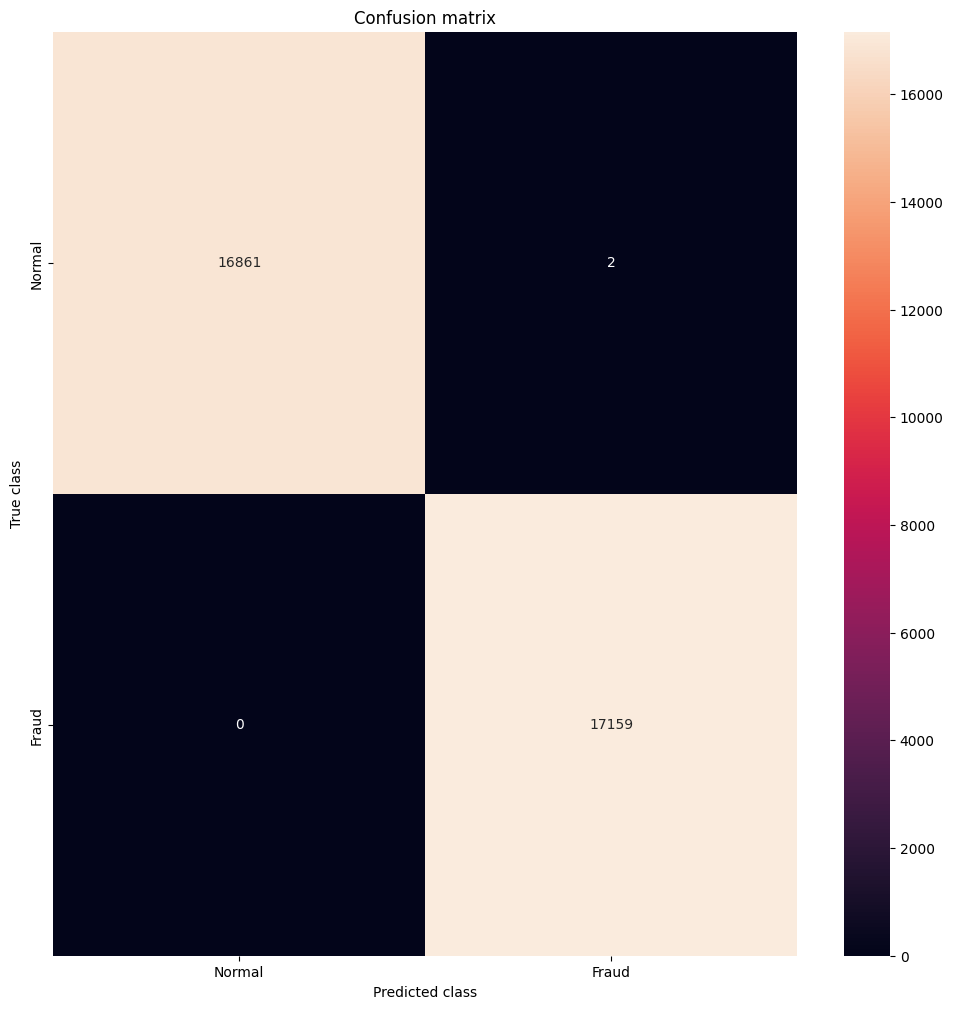

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABELS = ['Normal', 'Fraud']
conf_matrix =confusion_matrix(yTest, yPred)
plt.figure(figsize =(12, 12))
sns.heatmap(conf_matrix, xticklabels = LABELS,
yticklabels = LABELS, annot = True, fmt ="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()


In [25]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix


print("The model used is Random Forest classifier")

acc = accuracy_score(yTest, yPred)
print("The accuracy is {}".format(acc))

prec = precision_score(yTest, yPred)
print("The precision is {}".format(prec))

rec = recall_score(yTest, yPred)
print("The recall is {}".format(rec))

f1 = f1_score(yTest, yPred)
print("The F1-Score is {}".format(f1))


The model used is Random Forest classifier
The accuracy is 0.9999412145082593
The precision is 0.999883456675019
The recall is 1.0
The F1-Score is 0.999941724941725


In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear')
lr.fit(xTrain,yTrain)
y1Preds = lr.predict(xTest)

In [27]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
print("The model used is Logistic Regression Classifier")

acc = accuracy_score(yTest, y1Preds)
print("The accuracy is {}".format(acc))

prec = precision_score(yTest, y1Preds)
print("The precision is {}".format(prec))

rec = recall_score(yTest, y1Preds)
print("The recall is {}".format(rec))

f1 = f1_score(yTest, y1Preds)
print("The F1-Score is {}".format(f1))


The model used is Logistic Regression Classifier
The accuracy is 0.9647874904473576
The precision is 0.9788778877887789
The recall is 0.9506964275307419
The F1-Score is 0.964581362346263


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(xTrain, yTrain)
y2Preds = knn.predict(xTest)


In [ ]:
n_outliers = len(fraud)
n_errors = (y2Preds != yTest).sum()
from sklearn.metrics import classification_report
print("The model used is Logistic Regression Classifier")
print(classification_report(yTest, y2Preds))
acc = accuracy_score(yTest, y2Preds)
print("The accuracy is {}".format(acc))

prec = precision_score(yTest, y2Preds)
print("The precision is {}".format(prec))

rec = recall_score(yTest, y2Preds)
print("The recall is {}".format(rec))

f1 = f1_score(yTest, y2Preds)
print("The F1-Score is {}".format(f1))

In [ ]:
from sklearn import svm
s_model = svm.SVC(kernel = 'linear', random_state = 0)
s_model.fit(xTrain,yTrain)
y3preds = s_model.predict(xTest)

In [ ]:
from sklearn.metricsimport classification_report
print("The model used is SVM Classifier")
print(classification_report(yTest, y3preds))